# AI Agent Tool Calling Lab

This notebook demonstrates how to build AI agents that can call external tools. It covers weather lookups, structured tool definitions, LangChain and LangGraph agents, web search, and Amazon Bedrock's OpenAI-compatible endpoint.

In [1]:
#pip install openai langchain==1.2.15 langchain-core==1.2.26 langchain-openai==1.1.7 ddgs==9.10.0

In [ ]:
import os
os.environ["OPENAI_API_KEY"]="****"
os.environ["OPENAI_BASE_URL"]="https://bedrock-mantle.us-east-1.api.aws/v1"
os.environ["OPENAI_PROJECT_ID"]="default"

In [3]:
# ---------------------------------------------------------
# Step 1: Implement the tool
# ---------------------------------------------------------
# You can either:
#   (a) Call a real weather API (for example, OpenWeatherMap), or
#   (b) Create a dummy function that returns a fixed response (e.g., "It is 23°C and sunny in San Francisco.")
#
# Output:
#   • Return a short, human-readable sentence describing the weather.
#
# Example expected behavior:
#   get_current_weather("San Francisco") → "It is 23°C and sunny in San Francisco."
#

import json
from datetime import datetime
from urllib.error import URLError
from urllib.parse import urlencode
from urllib.request import urlopen

WEATHER_DESCRIPTIONS = {
    0: "clear skies", 1: "mainly clear skies", 2: "partly cloudy skies",
    3: "overcast skies", 45: "fog", 48: "freezing fog",
    51: "light drizzle", 53: "drizzle", 55: "heavy drizzle",
    56: "light freezing drizzle", 57: "freezing drizzle",
    61: "light rain", 63: "rain", 65: "heavy rain",
    66: "light freezing rain", 67: "freezing rain",
    71: "light snow", 73: "snow", 75: "heavy snow", 77: "snow grains",
    80: "light rain showers", 81: "rain showers", 82: "heavy rain showers",
    85: "light snow showers", 86: "heavy snow showers",
    95: "a thunderstorm", 96: "a thunderstorm with hail",
    99: "a severe thunderstorm with hail",
}

def _fetch_current_weather(city: str, unit: str) -> str:
    city = city.strip()
    unit = unit.strip().lower()
    if not city:
        return "Please provide a city name."
    if unit not in {"celsius", "fahrenheit"}:
        return "Unit must be either celsius or fahrenheit."

    try:
        geo_url = "https://geocoding-api.open-meteo.com/v1/search?" + urlencode(
            {"name": city, "count": 1, "language": "en", "format": "json"}
        )
        with urlopen(geo_url, timeout=10) as response:
            locations = json.load(response).get("results", [])

        if not locations:
            return f"I could not find a city named {city}."

        location = locations[0]
        weather_url = "https://api.open-meteo.com/v1/forecast?" + urlencode({
            "latitude": location["latitude"],
            "longitude": location["longitude"],
            "current": "temperature_2m,weather_code",
            "temperature_unit": unit,
            "timezone": "auto",
        })
        with urlopen(weather_url, timeout=10) as response:
            current = json.load(response)["current"]

        place = ", ".join(filter(None, [
            location.get("name"), location.get("admin1"), location.get("country")
        ]))
        description = WEATHER_DESCRIPTIONS.get(current["weather_code"], "unknown conditions")
        observed_at = datetime.fromisoformat(current["time"]).strftime("%B %d, %Y at %I:%M %p")
        temperature_symbol = "°C" if unit == "celsius" else "°F"
        return (
            f"As of {observed_at} local time, it is "
            f"{current['temperature_2m']:g}{temperature_symbol} with {description} in {place} "
            f"(latitude {location['latitude']:.4f}, longitude {location['longitude']:.4f})."
        )
    except (URLError, TimeoutError, json.JSONDecodeError, KeyError, TypeError, ValueError):
        return f"I could not retrieve the current weather for {city}."

def get_current_weather(city: str, unit: str = "celsius") -> str:
    """Return current weather, local time, and coordinates for a city.

    Args:
        city: City name to look up.
        unit: Temperature unit, either celsius or fahrenheit.
    """
    return _fetch_current_weather(city, unit)

In [4]:
response = get_current_weather(city="San Francisco")
print(response)

As of August 01, 2026 at 02:30 PM local time, it is 24.7°C with clear skies in San Francisco, California, United States (latitude 37.7749, longitude -122.4194).


In [5]:
# ----------------------------------------------------------------------
# Step 2: Create a prompt to teach the LLM when and how to use your tool
# ----------------------------------------------------------------------
# What to include:
#   • A SYSTEM_PROMPT that tells the model about the tool use and describes the tool
#   • A USER_QUESTION with a user query that should trigger the tool.
#       Example: "What is the weather in San Diego today?"

SYSTEM_PROMPT = """You are a helpful assistant with access to this tool:
- get_current_weather(city: str, unit: str = \"celsius\"): Returns the current local date, time, temperature,
  weather conditions, latitude, and longitude for a city.

When the user asks about the current weather, do not guess or answer from memory.
Respond with exactly one tool request in this format and no additional text:
TOOL_CALL: {\"name\": \"get_current_weather\", \"args\": {\"city\": \"<city>\"}}
Use the city name supplied by the user in place of <city>.
For requests unrelated to current weather, answer normally."""

USER_QUESTION = "How is the weather in San Francisco today?"

In [6]:
# ---------------------------------------------------------
# Step 3: Call the LLM with your prompt
# ---------------------------------------------------------
# Task:
#   Send SYSTEM_PROMPT + USER_QUESTION to the model.
#
# Steps:
#   1. Create an OpenAI-compatible client
#   2. Use chat.completions.create to send your prompt to google.gemma-3-4b-it
#   3. Print the response.
#
# Expected:
#   The model should return something like:
#   TOOL_CALL: {"name": "get_current_weather", "args": {"city": "San Diego"}}
# ---------------------------------------------------------
from openai import OpenAI

client = OpenAI()
prompt = f"{SYSTEM_PROMPT}\n\nUser question:\n{USER_QUESTION}"

response = client.chat.completions.create(
    model="google.gemma-3-4b-it",
    max_tokens=100,
    messages=[
        {"role": "user", "content": prompt},
    ],
)

model_output = response.choices[0].message.content
print(model_output)

TOOL_CALL: {"name": "get_current_weather", "args": {"city": "San Francisco"}}


In [7]:
# ---------------------------------------------------------
# Step 4: Manually parse the LLM output and call the tool
# ---------------------------------------------------------
# Task:
#   Detect when the model requests a tool, extract its name and arguments,
#   and execute the corresponding function.
#
# Steps:
#   1. Search for the text pattern "TOOL_CALL:{...}" in the model output.
#   2. Parse the JSON inside it to get the tool name and args.
#   3. Call the matching function (e.g., get_current_weather).
#
# Expected:
#   You should see a line like:
#       Calling tool `get_current_weather` with args {'city': 'San Diego'}
#       Result: It is 23°C and sunny in San Diego.
# ---------------------------------------------------------

import re, json, ast


def _extract_json_after_tool_call(text: str) -> str | None:
    m = re.search(r'TOOL_CALL\s*:\s*', text)
    if not m:
        return None
    start = m.end()
    idx = text.find('{', start)
    if idx == -1:
        return None
    i = idx
    stack = []
    while i < len(text):
        ch = text[i]
        if ch == '{':
            stack.append('{')
        elif ch == '}':
            if not stack:
                # unmatched closing brace
                return None
            stack.pop()
            if not stack:
                return text[idx:i + 1]
        i += 1
    return None

json_text = _extract_json_after_tool_call(model_output)
if not json_text:
    print("No TOOL_CALL JSON found or braces are unbalanced in model output")
else:
    try:
        try:
            payload = json.loads(json_text)
        except json.JSONDecodeError:
            # Try parsing Python-style dicts (single quotes) via ast.literal_eval
            payload = ast.literal_eval(json_text)
            if not isinstance(payload, dict):
                raise ValueError("Extracted payload is not a dict")

        tool_name = payload.get("name")
        tool_args = payload.get("args", {}) or {}

        print(f"Calling tool `{tool_name}` with args {tool_args}")

        tool_obj = globals().get(tool_name)
        if tool_obj is None:
            raise NameError(f"Tool '{tool_name}' not found in globals")

        # Support different tool object shapes
        if hasattr(tool_obj, "func") and callable(tool_obj.func):
            result = tool_obj.func(**tool_args)
        elif hasattr(tool_obj, "run") and callable(tool_obj.run):
            result = tool_obj.run(**tool_args)
        elif callable(tool_obj):
            result = tool_obj(**tool_args)
        else:
            raise TypeError(f"Tool '{tool_name}' is not callable")

        print("Result:", result)
    except Exception as e:
        print("Error parsing or calling tool:", repr(e))


Calling tool `get_current_weather` with args {'city': 'San Francisco'}
Result: As of August 01, 2026 at 02:30 PM local time, it is 24.7°C with clear skies in San Francisco, California, United States (latitude 37.7749, longitude -122.4194).


In [8]:
# ---------------------------------------------------------
# Generate a JSON schema for a tool automatically
# ---------------------------------------------------------
#
# Steps:
#   1. Rewrite the get_current_weather function with docstring and arg types
#   2. Use `inspect.signature` to automatically get function parameters and docstring
#   2. For each argument, record its name, type, and description.
#   3. Build a schema containing: name, description, and parameters.
#   4. Test your helper on `get_current_weather` and print the result.
#
# Expected:
#   A dictionary describing the tool (its name, args, and types).
# ---------------------------------------------------------

from pprint import pprint
import inspect

def get_current_weather(city: str, unit: str = "celsius") -> str:
    """Return current weather, local time, and coordinates for a city.

    Args:
        city: City name to look up.
        unit: Temperature unit, either celsius or fahrenheit.
    """
    return _fetch_current_weather(city, unit)

def to_schema(fn):
    sig = inspect.signature(fn)
    doc = inspect.getdoc(fn) or ""
    type_map = {str: "string", int: "integer", float: "number", bool: "boolean"}
    descriptions = {}
    for line in doc.splitlines():
        name, separator, description = line.strip().partition(":")
        if separator and name in sig.parameters:
            descriptions[name] = description.strip()

    properties, required = {}, []
    for name, parameter in sig.parameters.items():
        parameter_schema = {
            "type": type_map.get(parameter.annotation, "string"),
            "description": descriptions.get(name, f"Value for {name}."),
        }
        if parameter.default is inspect.Parameter.empty:
            required.append(name)
        else:
            parameter_schema["default"] = parameter.default
        properties[name] = parameter_schema

    return {
        "name": fn.__name__,
        "description": doc.splitlines()[0] if doc else "",
        "parameters": {"type": "object", "properties": properties, "required": required},
    }


tool_schema = to_schema(get_current_weather)
pprint(tool_schema)

{'description': 'Return current weather, local time, and coordinates for a '
                'city.',
 'name': 'get_current_weather',
 'parameters': {'properties': {'city': {'description': 'City name to look up.',
                                        'type': 'string'},
                               'unit': {'default': 'celsius',
                                        'description': 'Temperature unit, '
                                                       'either celsius or '
                                                       'fahrenheit.',
                                        'type': 'string'}},
                'required': ['city'],
                'type': 'object'}}


In [9]:
# ---------------------------------------------------------
# Provide the tool schema to the model instead of prompt surgery
# ---------------------------------------------------------
# Goal:
#   Give the model a "menu" of available tools so it can choose
#   which one to call based on the user’s question.
#
# Steps:
#   1. Add an extra system message (e.g., name="tool_spec")
#      containing the JSON schema(s) of your tools.
#   2. Include SYSTEM_PROMPT and the user question as before.
#   3. Send the messages to the model (google.gemma-3-4b-it).
#   4. Print the model output to see if it picks the right tool.
#
# Expected:
#   The model should produce a structured TOOL_CALL indicating
#   which tool to use and with what arguments.
# ---------------------------------------------------------


import json

tool_spec = json.dumps([tool_schema], indent=2)
prompt_with_tools = (
    f"{SYSTEM_PROMPT}\n\nAvailable tools:\n{tool_spec}"
    f"\n\nUser question:\n{USER_QUESTION}"
)

response = client.chat.completions.create(
    model="google.gemma-3-4b-it",
    max_tokens=150,
    messages=[
        {"role": "user", "content": prompt_with_tools},
    ],
)

model_output = response.choices[0].message.content
print(model_output)

TOOL_CALL: {"name": "get_current_weather", "args": {"city": "San Francisco"}}


In [10]:
# ---------------------------------------------------------
# Step 1: Define tools for LangChain
# ---------------------------------------------------------
# Steps:
#   1. Keep your existing `get_current_weather` function as before.
#   2. Add the `@tool` decorator to your function so LangChain can register it automatically.
#
# Notes:
#   • The decorator converts your Python function into a standardized tool object.

from langchain_core.tools import tool

@tool
def get_current_weather(city: str, unit: str = "celsius") -> str:
    """Get current weather, local time, latitude, and longitude for a city."""
    return _fetch_current_weather(city, unit)


In [11]:
# ---------------------------------------------------------
# Step 2: Create the Agent
# ---------------------------------------------------------
# Steps:
#   1. Create a google.gemma-3-4b-it LLM using the OpenAI-compatible API
#   2. Create the agent using create_agent
#   3. Test the agent with a natural question using agent.invoke

import os
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

llm = ChatOpenAI(
    model="google.gemma-3-4b-it",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
    max_tokens=200,
)

agent = create_agent(model=llm, tools=[get_current_weather])
result = agent.invoke({
    "messages": [{"role": "user", "content": "How is the weather in San Francisco today on 07/31/2026 at 4:00pm?"}]
})
print(result["messages"][-1].content)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Okay, let's look at the weather forecast for San Francisco on July 31, 2026, at 4:00 PM.

Unfortunately, I cannot give you a definitive weather forecast for a date that is over a year in the future. Weather forecasting becomes increasingly unreliable the further out you try to predict. 

However, I can provide you with how to get the most accurate forecast as that date gets closer:

**Here's how to find the best forecast as July 31, 2026, approaches:**

1. **Reliable Weather Websites (Check Regularly):**
   * **AccuWeather:** [https://www.accuweather.com/](https://www.accuweather.com/)
   * **The Weather Channel:** [https://weather.com/](https://weather.com/)
   * **National Weather Service (NWS):** [https://www.weather.


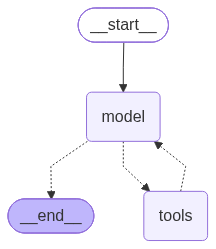

In [12]:
# ---------------------------------------------------------
# Step 2: Create the Agent
# ---------------------------------------------------------
# Steps:
#   1. Create a google.gemma-3-4b-it LLM using the OpenAI-compatible API
#   2. Create the agent using create_agent
#   3. Test the agent with a natural question using agent.invoke

import os
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

llm = ChatOpenAI(
    model="mistral.ministral-3-8b-instruct",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
    max_tokens=200,
)

agent = create_agent(model=llm, tools=[get_current_weather])
result = agent.invoke({
    "messages": [{"role": "user", "content": "Which places in california have the best weather today?"}]
})

agent

In [13]:

for message in result["messages"]:
    role = getattr(message, "role", getattr(message, "type", message.__class__.__name__))
    print(f"{role}: {message.content}")

print(result["messages"][-1].content)

human: Which places in california have the best weather today?
ai: 
tool: As of August 01, 2026 at 02:30 PM local time, it is 24.7°C with clear skies in San Francisco, California, United States (latitude 37.7749, longitude -122.4194).
tool: As of August 01, 2026 at 02:30 PM local time, it is 34.4°C with clear skies in Los Angeles, California, United States (latitude 34.0522, longitude -118.2437).
tool: As of August 01, 2026 at 02:30 PM local time, it is 28°C with clear skies in San Diego, California, United States (latitude 32.7157, longitude -117.1647).
tool: As of August 01, 2026 at 02:30 PM local time, it is 25.5°C with clear skies in Santa Barbara, California, United States (latitude 34.4208, longitude -119.6982).
tool: As of August 01, 2026 at 02:30 PM local time, it is 39.4°C with clear skies in Fresno, California, United States (latitude 36.7477, longitude -119.7724).
ai: Here’s a comparison of the current weather in some popular places across California as of **August 01, 2026*

In [14]:
# ---------------------------------------------------------
# Step 1: Write a web search tool
# ---------------------------------------------------------
# Steps:
#   1. Write a function (e.g., search_web) that:
#        • Takes a query string
#        • Uses DuckDuckGo (DDGS) to fetch top results (titles + URLs)
#        • Returns them as a formatted string
#   2. Add the `@tool` decorator so LangChain can register it automatically.


from ddgs import DDGS
from langchain_core.tools import tool

@tool
def search_web(query: str) -> str:
    """Search the web for current information and return the top results."""
    results = DDGS().text(query, max_results=5)
    if not results:
        return f"No web results found for: {query}"
    return "\n\n".join(
        f"{index}. {result.get('title', 'Untitled')}\n"
        f"URL: {result.get('href', '')}\n"
        f"Snippet: {result.get('body', '')}"
        for index, result in enumerate(results, start=1)
    )


In [15]:
# ---------------------------------------------------------
# Step 2: Initialize the web-search agent
# ---------------------------------------------------------
# Steps:
#   1. Create an OpenAI-compatible LLM.
#   2. Add your `search_web` tool to the tools list.
#   3. Create the agent using create_agent.
#
# Expected:
#   The agent should be ready to accept user queries
#   and use your web search tool when needed.
# ---------------------------------------------------------

import os
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

web_llm = ChatOpenAI(
    model="mistral.ministral-3-8b-instruct",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
    max_tokens=500,
)

agent = create_agent(model=web_llm, tools=[search_web, get_current_weather])

In [16]:
# ---------------------------------------------------------
# Step 3: Test your Ask-the-Web agent using agent.invoke
# ---------------------------------------------------------

result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "How can I enjoy in Sanfrancisco today also search web and let me know?",
    }]
})



Impersonate 'chrome_129' does not exist, using 'random'


In [17]:
for message in result["messages"]:
    role = getattr(message, "role", getattr(message, "type", message.__class__.__name__))
    print(f"{role}: {message.content}")



human: How can I enjoy in Sanfrancisco today also search web and let me know?
ai: 
tool: 1. Today in San Francisco: Events, Festivals, Concerts & More
URL: https://www.sftourismtips.com/today-in-san-francisco.html
Snippet: In addition to these fun activities today in San Francisco, you will also find several great events. On my monthly event calendars, you will find additional things to do. The weather in San Francisco is mild all year long. Our summers are moderate during the day and average temperatures in the mid-to-upper 60s.

2. THE 15 BEST Things to Do in San Francisco (2026)
URL: https://www.tripadvisor.com/Attractions-g60713-Activities-San_Francisco_California.html
Snippet: Ok this is a fun thing you can do in San Francisco - self guided walk. Dragons Gate is the start of the China Town area - very close to Union Square. Great history. Amazing sights and smells. And a must do is hunt out the original fortune cookie factory - it’s only a small place down one of the alley ways - 

In [18]:
print(result["messages"][-1].content)

San Francisco today has a mild and pleasant weather with a high around **24.7°C (76°F)**. Here are some great things to enjoy in San Francisco:

---

### **Outdoor Activities and Exploration**
1. **Explore Chinatown:**
   - Start your day with a **self-guided walk** through Chinatown, beginning at Dragons Gate. Enjoy the rich history, wonderful sights, and amazing smells.
   - Don’t forget to visit the **original fortune cookie factory** hidden down one of the alleys.

2. **Nature Walks:**
   - Head to **Golden Gate Park** to relax and take in sightseeing. There are several gardens and open spaces perfect for a leisurely stroll.

3. **Waterfront Experience:**
   - Walk along the **Embarcadero** for a fantastic view of San Francisco Bay, and visit historic pier areas like Pier 39.

---

### **Events and Entertainment**
1. **Cultural & Concert Events:**
   - Check Fever_up for today's **concerts, exhibitions, or museums** offering unique experiences.

2. **Summer with the Symphony:**
   

In [19]:
#pip install langchain-mistralai